##Traffic Analysis and ML models

Juan Esteban Monsalve Castrillón

##Importo las librerias a utilizar

In [ ]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

##Carga de datos

In [ ]:
# #Para cargar local
# # df = files.upload()
# data = pd.read_excel('Traffic_data.xlsx')

In [ ]:
#Importe desde Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

data = pd.read_excel('/content/drive/MyDrive/Traffic_data.xlsx')

Mounted at /content/drive


In [ ]:
data.head()
#Variable a predecir Traffic Situation

,Time,Time_2,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,weather,Traffic Situation
0,00:00:00,early morning,10,Tuesday,31,0,4,4,cloudy,low
1,00:15:00,early morning,10,Tuesday,49,0,3,3,rain,low
2,00:30:00,early morning,10,Tuesday,46,0,3,6,rain,low
3,00:45:00,early morning,10,Tuesday,51,0,2,5,cloudy,low
4,01:00:00,early morning,10,Tuesday,57,6,15,16,rain,low


In [ ]:
print(data.shape)

(2976, 10)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Time_2             2976 non-null   object
 2   Date               2976 non-null   int64 
 3   Day of the week    2976 non-null   object
 4   CarCount           2976 non-null   int64 
 5   BikeCount          2976 non-null   int64 
 6   BusCount           2976 non-null   int64 
 7   TruckCount         2976 non-null   int64 
 8   weather            2976 non-null   object
 9   Traffic Situation  2976 non-null   object
dtypes: int64(5), object(5)
memory usage: 232.6+ KB


In [ ]:
data.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount
count,2976.000000,2976.000000,2976.000000,2976.000000,2.976000e+03
mean,16.000000,68.595766,14.915995,15.278898,3.375539e+03
std,8.945775,46.001420,12.849079,14.342702,1.833086e+05
min,1.000000,-129.000000,-2.000000,-1.000000,0.000000e+00
25%,8.000000,19.000000,5.000000,1.000000,6.000000e+00
50%,16.000000,64.000000,12.000000,12.000000,1.400000e+01
75%,24.000000,107.000000,22.000000,25.000000,2.325000e+01
max,31.000000,180.000000,70.000000,50.000000,1.000000e+07


##Analisis de datos

###Corrección de outliers y ceros

In [ ]:
#Se revisaron los datos menores a 0 y les asignamos el promedio de la columna sin tener en cuenta los datos sin sentido(menores a 0)
data.loc[data['CarCount'] < 0, 'CarCount'] = data[data['CarCount'] >= 0]['CarCount'].mean()
data.loc[data['BikeCount'] < 0, 'BikeCount'] = data[data['BikeCount'] >= 0]['BikeCount'].mean()
data.loc[data['BusCount'] < 0, 'BusCount'] = data[data['BusCount'] >= 0]['BusCount'].mean()

<ipython-input-11-0db242b46c32>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '68.715438950555' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['CarCount'] < 0, 'CarCount'] = data[data['CarCount'] >= 0]['CarCount'].mean()
<ipython-input-11-0db242b46c32>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.921680672268907' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['BikeCount'] < 0, 'BikeCount'] = data[data['BikeCount'] >= 0]['BikeCount'].mean()
<ipython-input-11-0db242b46c32>:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15.28436974789916' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

In [ ]:
data.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount
count,2976.000000,2976.000000,2976.000000,2976.000000,2.976000e+03
mean,16.000000,68.715439,14.921681,15.284370,3.375539e+03
std,8.945775,45.812366,12.845334,14.339596,1.833086e+05
min,1.000000,6.000000,0.000000,0.000000,0.000000e+00
25%,8.000000,19.750000,5.000000,1.000000,6.000000e+00
50%,16.000000,64.000000,12.000000,12.000000,1.400000e+01
75%,24.000000,107.000000,22.000000,25.000000,2.325000e+01
max,31.000000,180.000000,70.000000,50.000000,1.000000e+07


In [ ]:
#Conteo de datos de 0 en el Dataset
#Columnas que tienen datos con valor cero
columnas_con_ceros = data.columns[(data == 0).any()]

#Cuantos valores ceros tiene cada columna
for columna in columnas_con_ceros:
    conteo_ceros = (data[columna] == 0).sum()
    print(f"Columna - {columna}: {conteo_ceros} ceros")

Columna - BikeCount: 145 ceros
Columna - BusCount: 437 ceros
Columna - TruckCount: 119 ceros


###Cambio de nombre de las variables

In [ ]:
#Se cambian las variables a sus respectivos nombres en español
data.columns = [
    'tiempo', 'tiempo_2', 'dia_mes', 'dia_semana',
    'conteo_carros', 'conteo_bicicletas', 'conteo_buses', 'conteo_camiones', 'clima', 'situacion_trafico'
]

In [ ]:
#Se va a predecir la variable situacion_trafico
#Se elimino la variable 'tiempo' ya que nos se va a hacer un analisis temporal por horas y 'tiempo_2' me sustituye esa necesidad
data = data[['tiempo_2', 'dia_mes', 'dia_semana',
    'conteo_carros', 'conteo_bicicletas', 'conteo_buses', 'conteo_camiones', 'clima', 'situacion_trafico']]

###Correlación entre la data

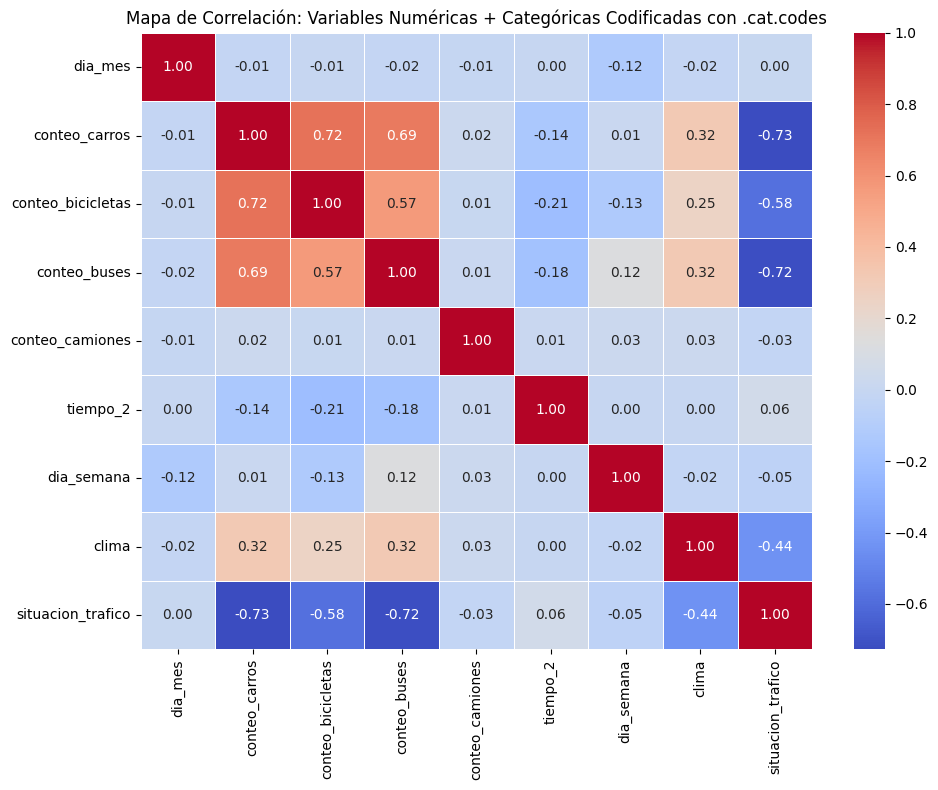

In [ ]:
#Separo las variables en numericas y categoricas. Luego se juntan en un mismo df
variables_numericas = ['dia_mes', 'conteo_carros', 'conteo_bicicletas', 'conteo_buses', 'conteo_camiones']
variables_categoricas = ['tiempo_2', 'dia_semana', 'clima', 'situacion_trafico']

data_subset = data[variables_numericas + variables_categoricas]

# Codificamos las variables
data_codificada = data_subset.copy()
for col in variables_categoricas:
    data_codificada[col] = data_codificada[col].astype('category').cat.codes

#Se crea la amtriz de correlacion y se muestra
matriz_correlacion = data_codificada.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlación: Variables Numéricas + Categóricas Codificadas con .cat.codes")
plt.tight_layout()
plt.show()

Se puede ver que las variables que tienen mayor conexión con la variable a analizar son 'conteo_carros', 'conteo_bicicletas', 'conteo_buses', 'clima', por lo que seran las variables que introduzcamos a ambos modelos para comprobar su efectividad

<ipython-input-22-25a851615856>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data['conteo_carros'], palette="pastel")


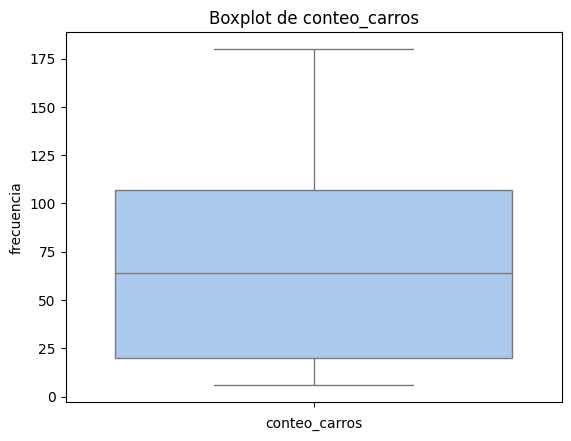

In [ ]:
#Grafica para la varaible conteo_carros
sns.boxplot(data['conteo_carros'], palette="pastel")

plt.title('Boxplot de conteo_carros')
plt.xlabel('conteo_carros')
plt.ylabel('frecuencia')
plt.show()

<ipython-input-23-3ea8836554ed>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data['conteo_bicicletas'], palette="pastel")


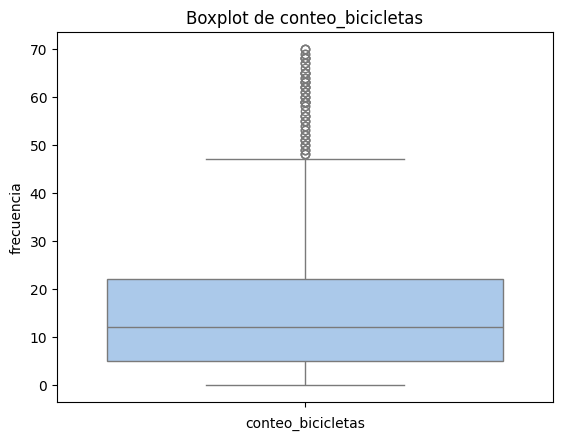

In [ ]:
#Grafica para la varaible conteo_bicicletas
sns.boxplot(data['conteo_bicicletas'], palette="pastel")

plt.title('Boxplot de conteo_bicicletas')
plt.xlabel('conteo_bicicletas')
plt.ylabel('frecuencia')
plt.show()

<ipython-input-24-f674f03668ae>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data['conteo_buses'], palette="pastel")


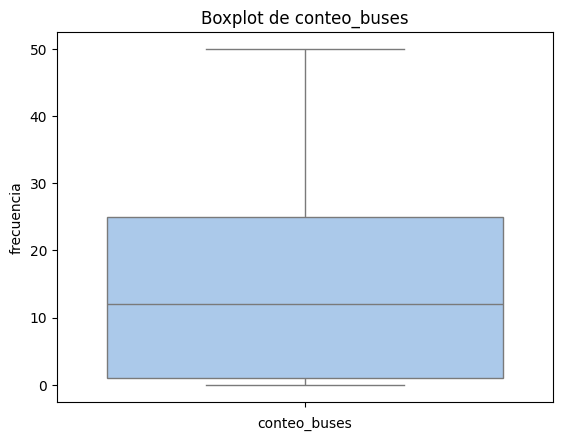

In [ ]:
#Grafica para la varaible conteo_buses
sns.boxplot(data['conteo_buses'], palette="pastel")

plt.title('Boxplot de conteo_buses')
plt.xlabel('conteo_buses')
plt.ylabel('frecuencia')
plt.show()

<ipython-input-25-e01fadfbf566>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clima', data=data, palette="pastel")


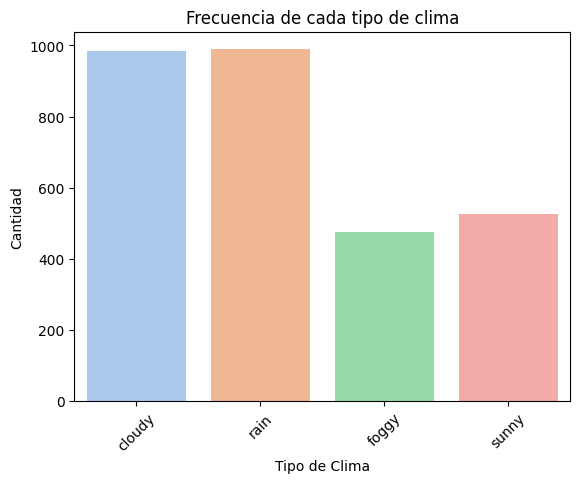

In [ ]:
#Diagrama para la variable clima
sns.countplot(x='clima', data=data, palette="pastel")

plt.title('Frecuencia de cada tipo de clima')
plt.xlabel('Tipo de Clima')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [ ]:
data_codificada.describe()

,dia_mes,conteo_carros,conteo_bicicletas,conteo_buses,conteo_camiones,tiempo_2,dia_semana,clima,situacion_trafico
count,2976.000000,2976.000000,2976.000000,2976.000000,2.976000e+03,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.715439,14.921681,15.284370,3.375539e+03,1.375000,3.193548,1.355175,0.662970
std,8.945775,45.812366,12.845334,14.339596,1.833086e+05,1.111211,2.007090,1.115450,0.472775
min,1.000000,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,8.000000,19.750000,5.000000,1.000000,6.000000e+00,0.000000,1.000000,0.000000,0.000000
50%,16.000000,64.000000,12.000000,12.000000,1.400000e+01,1.000000,3.000000,2.000000,1.000000
75%,24.000000,107.000000,22.000000,25.000000,2.325000e+01,2.000000,5.000000,2.000000,1.000000
max,31.000000,180.000000,70.000000,50.000000,1.000000e+07,3.000000,6.000000,3.000000,1.000000


##Modelo de predicción

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
#Separacion de datos. 80% para entrenar el modelo. 20% para la prediccion final.
train_size = int(len(data) * 0.8)
data_train = data_codificada.iloc[:train_size]
data_predict = data_codificada.iloc[train_size:]

data_train.count()

,0
dia_mes,2380
conteo_carros,2380
conteo_bicicletas,2380
conteo_buses,2380
conteo_camiones,2380
tiempo_2,2380
dia_semana,2380
clima,2380
situacion_trafico,2380


In [ ]:
data_predict.count()

,0
dia_mes,596
conteo_carros,596
conteo_bicicletas,596
conteo_buses,596
conteo_camiones,596
tiempo_2,596
dia_semana,596
clima,596
situacion_trafico,596


In [ ]:
#Se separan los datos con train_split
x = data_codificada.filter([ 'conteo_carros', 'conteo_bicicletas', 'conteo_buses', 'clima'])
y = data_codificada['situacion_trafico'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   conteo_carros      2976 non-null   float64
 1   conteo_bicicletas  2976 non-null   float64
 2   conteo_buses       2976 non-null   float64
 3   clima              2976 non-null   int8   
dtypes: float64(3), int8(1)
memory usage: 72.8 KB


In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2976 entries, 0 to 2975
Series name: situacion_trafico
Non-Null Count  Dtype
--------------  -----
2976 non-null   int64
dtypes: int64(1)
memory usage: 23.4 KB


###Modelado con Regresión Logistica

In [ ]:
modelo = LogisticRegression()
modelo.fit(X_train, y_train)
y_pred_rl = modelo.predict(X_test)

In [ ]:
matriz_rl = confusion_matrix(y_test, y_pred_rl)
print('Matriz de confusión')
print(matriz_rl)

Matriz de confusión
[[177  24]
 [ 18 377]]


In [ ]:
precision_rl = precision_score(y_test, y_pred_rl)
print('Precisión del modelo')
print(precision_rl)

Precisión del modelo
0.940149625935162


In [ ]:
recall_rl = recall_score(y_test, y_pred_rl)
print('Recall del modelo: ')
print(recall_rl)

Recall del modelo: 
0.9544303797468354


In [ ]:
f1_score_rl = f1_score(y_test, y_pred_rl)
print('F1 Score del modelo: ')
print(f1_score_rl)

F1 Score del modelo: 
0.9472361809045227


In [ ]:
accuracy = accuracy_score(y_test, y_pred_rl)
print('Accuracy del modelo: ')
print(accuracy)

Accuracy del modelo: 
0.9295302013422819


In [ ]:
#Test de accuracy
# Predicciones en entrenamiento y prueba
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

# Accuracy en entrenamiento y prueba
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Accuracy en entrenamiento: {train_acc:.4f}")
print(f"Accuracy en prueba: {test_acc:.4f}")

Accuracy en entrenamiento: 0.9210
Accuracy en prueba: 0.9295


###Modelado con Random Forest

In [ ]:
forest = RandomForestClassifier(bootstrap= True, max_depth= 10, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 2, n_estimators= 100)
forest.fit(X_train, y_train)
y_pred_rf = forest.predict(X_test)

In [ ]:
matriz_rf = confusion_matrix(y_test, y_pred_rf)
print('Matriz de confusión')
print(matriz_rf)

Matriz de confusión
[[200   1]
 [  1 394]]


In [ ]:
precision_rf = precision_score(y_test, y_pred_rf)
print('Precisión del modelo')
print(precision_rf)

Precisión del modelo
0.9974683544303797


In [ ]:
recall_rf = recall_score(y_test, y_pred_rf)
print('Recall del modelo: ')
print(recall_rf)

Recall del modelo: 
0.9974683544303797


In [ ]:
f1_score_rf = f1_score(y_test, y_pred_rf)
print('F1 Score del modelo: ')
print(f1_score_rf)

F1 Score del modelo: 
0.9974683544303797


In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Accuracy del modelo: ')
print(accuracy_rf)

Accuracy del modelo: 
0.9966442953020134


####Prueba de sobreajuste para Random Forest

In [ ]:
#Test de accuracy
# Predicciones en entrenamiento y prueba
y_train_pred = forest.predict(X_train)
y_test_pred = forest.predict(X_test)

# Accuracy en entrenamiento y prueba
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Accuracy en entrenamiento: {train_acc:.4f}")
print(f"Accuracy en prueba: {test_acc:.4f}")

Accuracy en entrenamiento: 1.0000
Accuracy en prueba: 0.9966


In [ ]:
#Prueba de Validacion cruzada
from sklearn.model_selection import cross_val_score
cross_val_scores = cross_val_score(forest, X_train, y_train, cv=5, scoring='accuracy')
print(f"Accuracy promedio de validación cruzada: {cross_val_scores.mean():.4f}")

Accuracy promedio de validación cruzada: 0.9958


##Analisis final del mejor modelo

Se ha seleccionado el modelo hecho con Random Forest ya que su precision estuvo en un 99.6% de los datos, y aunque pueda ser muy alto, se comprobo mediante las pruebas de accuracy (incluyendo los datos de prueba y entrenamiento), que son valores muy similares, por lo tanto indica que no hay sobreajuste. Tambien se le hizo una prueba de validación cruzada la cual dio indices muy altos tambien, lo que indica que el modelo tiene un excelente rendimiento promedio.

En conclusión, a pesar de tener una precisión de 100% en el entrenamiento, eso no está generando un mal rendimiento en los datos nuevos, por lo tanto, el modelo generaliza bien.

In [ ]:
#Ahora pruebo con nlos datos no involucrados en el entrenamiento, el 20% reservado almacenado en data_predict
X_predict = data_predict.filter([ 'conteo_carros', 'conteo_bicicletas', 'conteo_buses', 'clima'])
y_actual = data_predict['situacion_trafico']

In [ ]:
# Predecir con el modelo Random Forest
y_pred = forest.predict(X_predict)

In [ ]:
# Evaluar la precisión de los datos predichos
accuracy = accuracy_score(y_actual, y_pred)
print(f"Accuracy sobre el 20% reservado: {accuracy:.4f}")

# Matriz de confusión para comparar los datos reales y los predichos
print("\nMatriz de confusión:")
print(confusion_matrix(y_actual, y_pred))

Accuracy sobre el 20% reservado: 1.0000

Matriz de confusión:
[[210   0]
 [  0 386]]


En conclusion, se ha creado un modelo casi perfecto, que no solo tienen un alto rendimiento en los datos de entrenamiento, sino que tambien tiene un excelente rendimiento en los datos nuevos que se le ingresan.

##Conversión de Jupyter a PDF

In [ ]:
!jupyter nbconvert --to html "/content/TrafficML_JuanMonsalve.ipynb"

[NbConvertApp] WARNING | pattern '/content/TrafficML_JuanMonsalve.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes